In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [9]:
sentiment = pd.read_csv("C:\\Users\\ASUS\\Downloads\\historical_data.csv")

In [11]:
trades=pd.read_csv("C:\\Users\\ASUS\\Downloads\\fear_greed_index.csv")

In [13]:
sentiment.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
trades.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [17]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)


Sentiment Shape: (211224, 16)
Trades Shape: (2644, 4)


In [19]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [21]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [23]:
sentiment.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [25]:
trades.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [27]:
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

0
0


In [29]:
trader_df = sentiment.copy()
fear_df = trades.copy()

In [31]:
trader_df['Timestamp'].head()


0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [35]:
trader_df['Timestamp'] = pd.to_datetime(
    trader_df['Timestamp'],
    unit='ms'
)

In [37]:
trader_df['Date'] = trader_df['Timestamp'].dt.date

In [39]:
trader_df[['Timestamp','Date']].head()

,Timestamp,Date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27


In [41]:
fear_df['date'] = pd.to_datetime(fear_df['date'])
fear_df['Date'] = fear_df['date'].dt.date

In [43]:
print("Trader Range:")
print(trader_df['Date'].min())
print(trader_df['Date'].max())

print("\nFear-Greed Range:")
print(fear_df['Date'].min())
print(fear_df['Date'].max())

Trader Range:
2023-03-28
2025-06-15

Fear-Greed Range:
2018-02-01
2025-05-02


In [45]:
print("Trader duplicates:", trader_df.duplicated().sum())
print("Fear-Greed duplicates:", fear_df.duplicated().sum())

Trader duplicates: 0
Fear-Greed duplicates: 0


In [47]:
merged_df = pd.merge(
    trader_df,
    fear_df[['Date', 'classification']],
    on='Date',
    how='left'
)

In [49]:
merged_df.shape

(211224, 18)

In [51]:
merged_df['classification'].value_counts(dropna=False)


classification
Fear             133871
Greed             36289
NaN               26961
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

In [53]:
merged_df.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp',
 'Date',
 'classification']

In [55]:
daily_pnl = merged_df.groupby(
    ['Date', 'Account']
)['Closed PnL'].sum().reset_index()

daily_pnl.head()


,Date,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


In [57]:
daily_pnl.shape

(102, 3)

In [59]:
daily_trades = merged_df.groupby(
    ['Date', 'Account']
).size().reset_index(name='Trade Count')

daily_trades.head()

,Date,Account,Trade Count
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1043
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,27
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,88


In [61]:
merged_df['Win'] = (
    merged_df['Closed PnL'] > 0
).astype(int)


In [63]:
win_rate = merged_df.groupby(
    'Account'
)['Win'].mean().reset_index()

win_rate['Win Rate %'] = win_rate['Win'] * 100

win_rate.head()

,Account,Win,Win Rate %
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355


In [65]:
avg_trade_size = merged_df.groupby(
    ['Date', 'Account']
)['Size USD'].mean().reset_index()

avg_trade_size.rename(
    columns={'Size USD':'Avg Trade Size'},
    inplace=True
)

avg_trade_size.head()

,Date,Account,Avg Trade Size
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,159.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,23066.935000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11034.799511
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3048.594444
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,1136.312727


In [67]:
merged_df['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [69]:
sentiment_pnl = merged_df.groupby(
    'classification'
)['Closed PnL'].agg(
    ['count','mean','sum']
)

sentiment_pnl

,count,mean,sum
classification,,,
Extreme Greed,6962,25.418772,1.769655e+05
Fear,133871,50.047622,6.699925e+06
Greed,36289,87.894859,3.189617e+06
Neutral,7141,22.229713,1.587424e+05


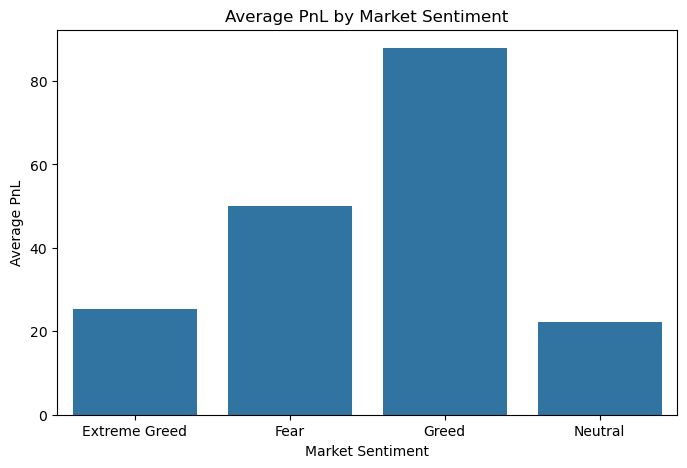

In [71]:
sentiment_avg_pnl = merged_df.groupby(
    'classification'
)['Closed PnL'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=sentiment_avg_pnl,
    x='classification',
    y='Closed PnL'
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.show()

In [73]:
trade_frequency = merged_df.groupby(
    'classification'
).size().reset_index(name='Trade Count')

trade_frequency

,classification,Trade Count
0,Extreme Greed,6962
1,Fear,133871
2,Greed,36289
3,Neutral,7141


In [75]:
trade_size = merged_df.groupby(
    'classification'
)['Size USD'].mean().reset_index()

trade_size


,classification,Size USD
0,Extreme Greed,5660.265764
1,Fear,5259.977837
2,Greed,3182.883845
3,Neutral,3058.848110


In [77]:
merged_df['Trade Type'] = np.where(
    merged_df['Direction'].str.contains('Long', case=False, na=False),
    'Long',
    np.where(
        merged_df['Direction'].str.contains('Short', case=False, na=False),
        'Short',
        'Other'
    )
)


In [79]:
merged_df['Trade Type'].value_counts()

Trade Type
Long     98700
Short    75755
Other    36769
Name: count, dtype: int64

In [81]:
long_short = pd.crosstab(
    merged_df['classification'],
    merged_df['Trade Type']
)

long_short


Trade Type,Long,Other,Short
classification,,,
Extreme Greed,3754,163,3045
Fear,74462,15705,43704
Greed,10596,15678,10015
Neutral,1806,1147,4188


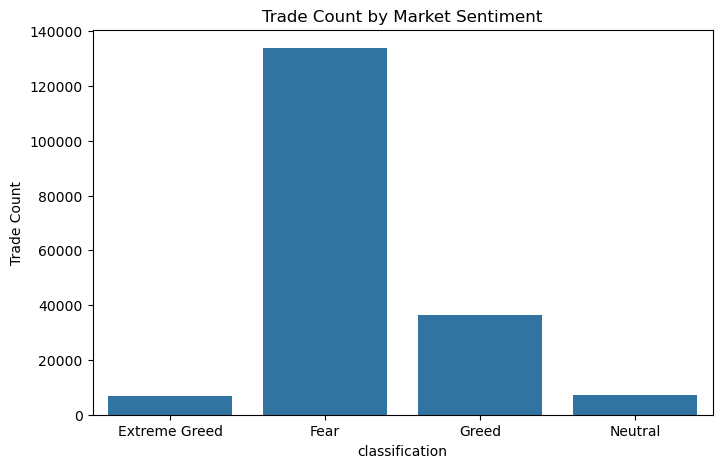

In [83]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=trade_frequency,
    x='classification',
    y='Trade Count'
)

plt.title('Trade Count by Market Sentiment')
plt.show()


In [85]:
long_short['Long Ratio %'] = (
    long_short['Long'] /
    (long_short['Long'] + long_short['Short'])
) * 100

long_short[['Long','Short','Long Ratio %']]

Trade Type,Long,Short,Long Ratio %
classification,,,
Extreme Greed,3754,3045,55.214002
Fear,74462,43704,63.014742
Greed,10596,10015,51.409442
Neutral,1806,4188,30.130130


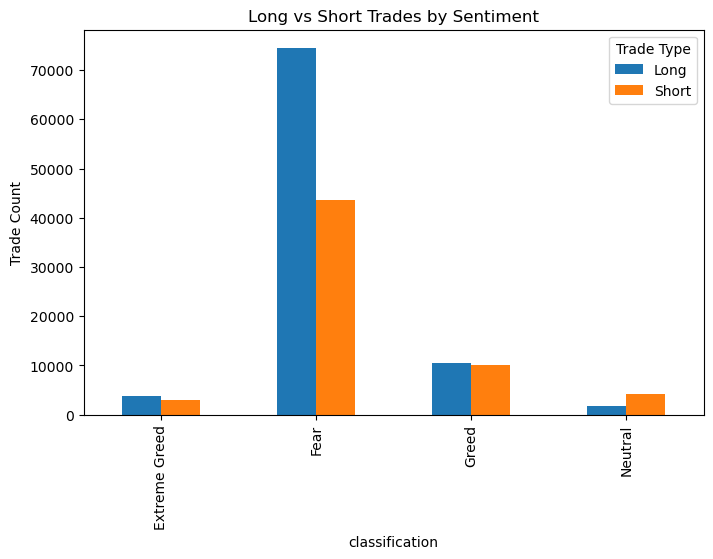

In [87]:
long_short[['Long','Short']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Long vs Short Trades by Sentiment')
plt.ylabel('Trade Count')
plt.show()

In [89]:
trader_summary = merged_df.groupby(
    'Account'
).agg({
    'Closed PnL':'sum',
    'Size USD':'mean',
    'Trade ID':'count'
}).reset_index()

trader_summary.columns = [
    'Account',
    'Total PnL',
    'Avg Trade Size',
    'Trade Count'
]

trader_summary.head()



,Account,Total PnL,Avg Trade Size,Trade Count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,1653.226327,7280
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,8893.000898,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,507.626933,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,3138.894782,3239


In [91]:
trader_summary['Profit Segment'] = np.where(
    trader_summary['Total PnL'] > 0,
    'Winner',
    'Loser'
)

In [93]:
trader_summary['Profit Segment'].value_counts()


Profit Segment
Winner    29
Loser      3
Name: count, dtype: int64

In [101]:
segment_analysis = trader_summary.groupby(
    'Profit Segment'
).agg({
    'Total PnL':'mean',
    'Avg Trade Size':'mean',
    'Trade Count':'mean'
})

segment_analysis

,Total PnL,Avg Trade Size,Trade Count
Profit Segment,,,
Loser,-89753.638695,4275.875845,3075.000000
Winner,364352.408949,6187.107321,6965.482759


In [107]:
median_trades = trader_summary['Trade Count'].median()

median_trades

3699.0

In [103]:
trader_summary['Frequency Segment'] = np.where(
    trader_summary['Trade Count'] >= median_trades,
    'Frequent',
    'Infrequent'
)

In [105]:
trader_summary['Frequency Segment'].value_counts()

Frequency Segment
Frequent      16
Infrequent    16
Name: count, dtype: int64

In [113]:
frequency_analysis = trader_summary.groupby(
    'Frequency Segment'
).agg({
    'Total PnL':'mean',
    'Avg Trade Size':'mean',
    'Trade Count':'mean'
})

frequency_analysis

,Total PnL,Avg Trade Size,Trade Count
Frequency Segment,,,
Frequent,496527.661215,7912.913954,11684.8125
Infrequent,147032.272750,4102.944786,1516.6875


In [111]:
median_size = trader_summary['Avg Trade Size'].median()

median_size

3327.972048158659

In [115]:
trader_summary['Size Segment'] = np.where(
    trader_summary['Avg Trade Size'] >= median_size,
    'Large Position',
    'Small Position'
)

In [117]:
size_analysis = trader_summary.groupby(
    'Size Segment'
).agg({
    'Total PnL':'mean',
    'Avg Trade Size':'mean',
    'Trade Count':'mean'
})

size_analysis

,Total PnL,Avg Trade Size,Trade Count
Size Segment,,,
Large Position,416805.966542,10151.775075,4185.3125
Small Position,226753.967423,1864.083665,9016.1875


In [119]:
segment_analysis = trader_summary.groupby(
    'Profit Segment'
).agg({
    'Total PnL':'mean',
    'Avg Trade Size':'mean',
    'Trade Count':'mean'
})

segment_analysis

,Total PnL,Avg Trade Size,Trade Count
Profit Segment,,,
Loser,-89753.638695,4275.875845,3075.000000
Winner,364352.408949,6187.107321,6965.482759


In [121]:
trade_size = merged_df.groupby(
    'classification'
)['Size USD'].mean().reset_index()

trade_size


,classification,Size USD
0,Extreme Greed,5660.265764
1,Fear,5259.977837
2,Greed,3182.883845
3,Neutral,3058.848110
